# Tutorial 4: Large-scale Brain Atlas Analysis

This tutorial demonstrates spatial analysis of a large-scale MERFISH whole-brain atlas
(~8.4 million cells across 239 brain sections from 4 animals). We use `spatial_query_multi`
to discover spatial motifs surrounding glutamatergic neurons, examine their regional
distribution, perform cross-cell gene-gene covariation analysis, and compare motif-specific
covarying gene programs across brain regions.

**Dataset:** Allen Institute WB-MERFISH adult mouse brain atlas
**API class:** `spatial_query_multi`

## 1. Setup

In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
import anndata as ad
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from SpatialQuery import spatial_query_multi

## 2. Load Data

The MERFISH atlas consists of 4 animals (2 coronal, 2 sagittal) with 239 brain sections total.

In [3]:
DATA_DIR = "../data/merfish_mouse_brain"

files = [f for f in os.listdir(DATA_DIR) if f.endswith(".h5ad")]
adatas = [ad.read_h5ad(os.path.join(DATA_DIR, f)) for f in files]
adatas[0]

AnnData object with n_obs × n_vars = 1915592 × 1120
    obs: 'donor_id', 'development_stage_ontology_term_id', 'sex_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'disease_ontology_term_id', 'tissue_ontology_term_id', 'cell_type_ontology_term_id', 'assay_ontology_term_id', 'suspension_type', 'cluster_id_transfer', 'subclass_transfer', 'cluster_confidence_score', 'subclass_confidence_score', 'high_quality_transfer', 'major_brain_region', 'ccf_region_name', 'brain_section_label', 'tissue_type', 'is_primary_data', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid'
    var: 'gene_name', 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type'
    uns: 'citation', 'organism', 'organism_ontology_term_id', 'schema_reference', 'schema_version', 'title'
    obsm: 'X_CCF', 'X_spatial_coords', 'X_umap'

In [4]:
# Split each animal into individual brain sections
adatas_fov = []
dataset_names = []
for adata in adatas:
    dataset_name = adata.uns["title"]
    for label in adata.obs["brain_section_label"].unique():
        adatas_fov.append(adata[adata.obs["brain_section_label"] == label].copy())
    dataset_names.extend([dataset_name] * len(adata.obs["brain_section_label"].unique()))

print(f"Total FOVs: {len(adatas_fov)}")
print(f"Total cells: {sum(a.n_obs for a in adatas_fov):,}")

Total FOVs: 239
Total cells: 8,380,288


In [5]:
print(f'Max value: {adata.X.max()}, min value: {adata.X.min()}')

Max value: 6.908754825592041, min value: 0.0


Data is already log-normalized. We skip normalization during initialization (`if_lognorm=False`).

## 3. Initialize SpatialQuery Multi

In [6]:
# ---- Configuration: adjust these to match your dataset ----
spatial_key = "X_spatial_coords"
label_key = "cell_type"
feature_name = "gene_name"

In [7]:
spm = spatial_query_multi(
    adatas_fov,
    datasets=dataset_names,
    spatial_key=spatial_key,
    label_key=label_key,
    feature_name=feature_name,
    build_gene_index=False,
    if_lognorm=False,
    if_normalize_spatial_coord=True,
)

Replacing _ with hyphen in WB_MERFISH_animal2_coronal.
Replacing _ with hyphen in WB_MERFISH_animal2_coronal.
Replacing _ with hyphen in WB_MERFISH_animal2_coronal.
Replacing _ with hyphen in WB_MERFISH_animal2_coronal.
Replacing _ with hyphen in WB_MERFISH_animal2_coronal.
Replacing _ with hyphen in WB_MERFISH_animal2_coronal.
Replacing _ with hyphen in WB_MERFISH_animal2_coronal.
Replacing _ with hyphen in WB_MERFISH_animal2_coronal.
Replacing _ with hyphen in WB_MERFISH_animal2_coronal.
Replacing _ with hyphen in WB_MERFISH_animal2_coronal.
... (1183 lines omitted) ...
Scale factor: 0.0843
build_gene_index is False. Using adata.X for gene expression analysis.


In [8]:
valid_ds_names = sorted(set(d.split("_")[0] for d in spm.datasets))
print(valid_ds_names)

['WB-MERFISH-animal1-coronal', 'WB-MERFISH-animal2-coronal', 'WB-MERFISH-animal3-sagittal', 'WB-MERFISH-animal4-sagittal']


## 4. Cell Type Composition

/var/folders/wl/y90xsxr94l78931lqz6nyvz80000gp/T/ipykernel_31656/3661813038.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(name)
/var/folders/wl/y90xsxr94l78931lqz6nyvz80000gp/T/ipykernel_31656/3661813038.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(name)
/Users/sa3520/BWH/spatial query/python/SpatialQuery/spatial_query_multiple_fov.py:1441: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(colorma

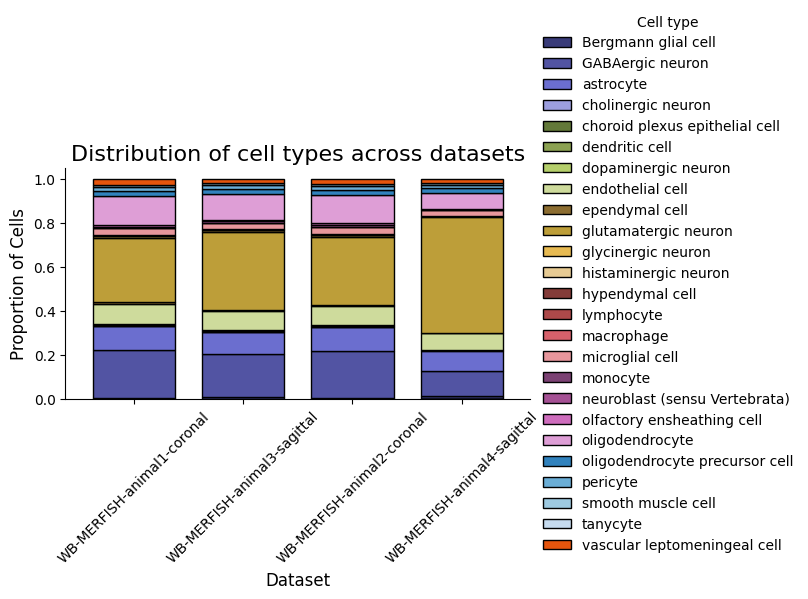

In [9]:
from matplotlib.colors import ListedColormap
import matplotlib.cm as cm

# Combine tab20b + tab20c for 40 unique colors (needed when >20 cell types)
all_colors = []
for name in ["tab20b", "tab20c"]:
    cmap = cm.get_cmap(name)
    all_colors.extend([cmap(i) for i in range(cmap.N)])

seen = set()
unique_colors = []
for c in all_colors:
    key = tuple(round(v, 4) for v in c)
    if key not in seen:
        seen.add(key)
        unique_colors.append(c)

custom_cmap = ListedColormap(unique_colors, name="tab40")

spm.plot_cell_type_distribution(colormap=custom_cmap)

## 5. Motif Enrichment Analysis

Discover enriched motifs surrounding **glutamatergic neurons** in coronal sections.
We restrict to coronal datasets for consistency across animals.

In [10]:
anchor_ct = 'glutamatergic neuron'
max_dist = 5
min_support = 0.5

coronal_ds = ['WB-MERFISH-animal1-coronal', 'WB-MERFISH-animal2-coronal']

motif_glut_coronal_df, motif_glut_coronal_motif_id, motif_glut_coronal_center_id = spm.motif_enrichment_dist(
    ct=anchor_ct,
    dataset=coronal_ds,
    max_dist=max_dist,
    min_support=min_support,
    return_cellID=True
)

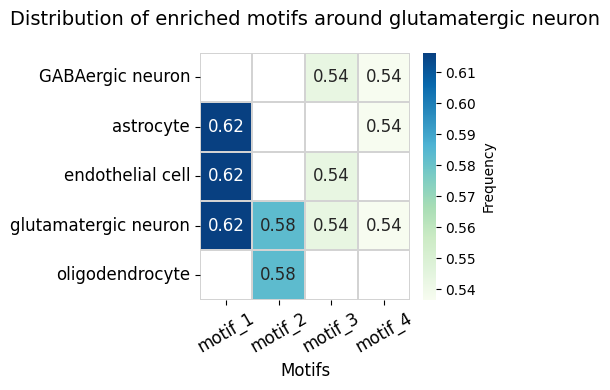

In [11]:
from SpatialQuery.plotting import plot_motif_enrichment_heatmap
plot_motif_enrichment_heatmap(enrich_df=motif_glut_coronal_df, 
                              figsize=(5, 4), 
                              )

In [12]:
# Collect motif+ / motif- obs for each motif

data_by_motif = {}
for motif_idx in range(len(motif_glut_coronal_df)):
    motifs_list = motif_glut_coronal_df.iloc[motif_idx]['motifs']
    outer_key = str(sorted(motifs_list))
    center_id_dict = motif_glut_coronal_center_id.get(outer_key, {})

    pos_obs_list, neg_obs_list = [], []
    for sp, fov_ds in zip(spm.spatial_queries, spm.datasets):
        if not any(fov_ds.startswith(td) for td in coronal_ds):
            continue
        obs = sp.adata.obs.copy()
        ct_mask = obs[label_key] == anchor_ct
        pos_indices = center_id_dict.get(fov_ds, [])
        if len(pos_indices) > 0:
            pos_mask = np.zeros(len(obs), dtype=bool)
            pos_mask[np.asarray(pos_indices)] = True
            pos_obs_list.append(obs[pos_mask & ct_mask])
            neg_obs_list.append(obs[ct_mask & ~pos_mask])
        else:
            neg_obs_list.append(obs[ct_mask])

    pos_obs = pd.concat(pos_obs_list, ignore_index=True) if pos_obs_list else pd.DataFrame()
    neg_obs = pd.concat(neg_obs_list, ignore_index=True) if neg_obs_list else pd.DataFrame()
    motif_label = '+'.join(sorted([m for m in motifs_list if m != anchor_ct])) or 'Self'
    data_by_motif[motif_idx] = dict(pos_obs=pos_obs, neg_obs=neg_obs, motif_label=motif_label)


/var/folders/wl/y90xsxr94l78931lqz6nyvz80000gp/T/ipykernel_31656/514646767.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('Set2', len(top_subs))


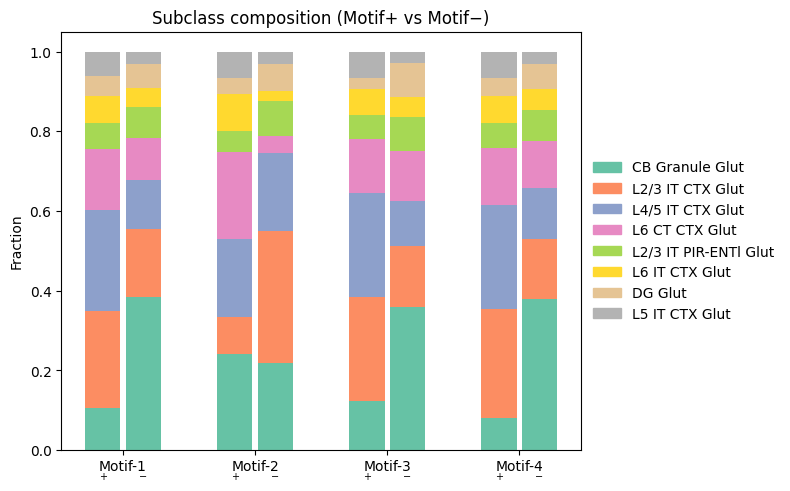

In [13]:
# Subclass composition (motif+ vs motif-) per motif
import matplotlib.patches as mpatches

all_obs = pd.concat(
    [d['pos_obs'] for d in data_by_motif.values()] +
    [d['neg_obs'] for d in data_by_motif.values()],
    ignore_index=True
)
top_subs = all_obs['subclass_transfer'].value_counts().index[:8].tolist()

n_motifs = len(data_by_motif)
bar_w, gap = 0.35, 0.05
x_centers = np.arange(n_motifs) * 1.3
cmap = plt.cm.get_cmap('Set2', len(top_subs))
sub_colors = {s: cmap(i) for i, s in enumerate(top_subs)}

fig, ax = plt.subplots(figsize=(max(6, n_motifs * 2), 5))
for motif_idx, d in data_by_motif.items():
    for obs_df, x_bar in [(d['pos_obs'], x_centers[motif_idx]),
                           (d['neg_obs'], x_centers[motif_idx] + bar_w + gap)]:
        if len(obs_df) == 0:
            continue
        counts = obs_df['subclass_transfer'].value_counts(normalize=True)
        top_fracs = {sub: counts.get(sub, 0.0) for sub in top_subs}
        total_top = sum(top_fracs.values())
        if total_top == 0:
            continue
        bottom = 0.0
        for sub in top_subs:
            frac = top_fracs[sub] / total_top
            ax.bar(x_bar, frac, bar_w, bottom=bottom, color=sub_colors[sub])
            bottom += frac

tick_pos = [x_centers[i] + (bar_w + gap) / 2 for i in range(n_motifs)]
ax.set_xticks(tick_pos)
ax.set_xticklabels([f'Motif-{i+1}' for i in range(n_motifs)])
for i in range(n_motifs):
    ax.text(x_centers[i], -0.05, '+', ha='center', va='top', fontsize=7, transform=ax.get_xaxis_transform())
    ax.text(x_centers[i] + bar_w + gap, -0.05, '−', ha='center', va='top', fontsize=7, transform=ax.get_xaxis_transform())

ax.legend(handles=[mpatches.Patch(color=sub_colors[s], label=s) for s in top_subs],
          loc='center left', bbox_to_anchor=(1, 0.5), frameon=False)
ax.set_ylabel('Fraction')
ax.set_title('Subclass composition (Motif+ vs Motif−)')
plt.tight_layout()


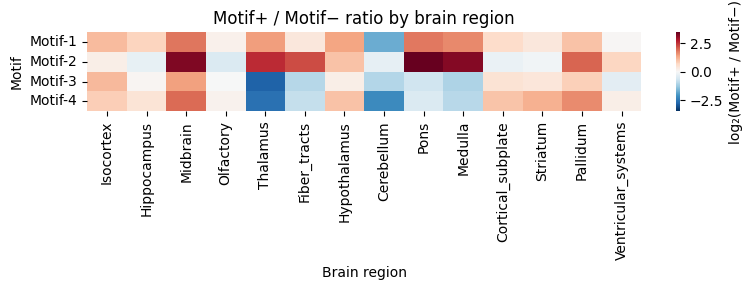

In [14]:
# Heatmap: Motif+ / Motif- ratio per brain region
region_order = list(data_by_motif[0]['pos_obs']['major_brain_region'].value_counts().index)

rows = {}
for motif_idx, d in data_by_motif.items():
    pos_region = d['pos_obs']['major_brain_region'].value_counts()
    neg_region = d['neg_obs']['major_brain_region'].value_counts()
    ratio = pd.Series({
        r: pos_region.get(r, 0) / max(neg_region.get(r, 0), 1)
        for r in region_order
    })
    rows[f'Motif-{motif_idx+1}'] = ratio

hm_df = pd.DataFrame(rows, index=region_order).T
log2_df = np.log2(hm_df.clip(lower=1e-6))
abs_max = np.nanmax(np.abs(log2_df.values))

fig, ax = plt.subplots(figsize=(8, max(3, n_motifs * 0.6)))
sns.heatmap(
    log2_df, ax=ax, cmap='RdBu_r',
    vmin=-abs_max, vmax=abs_max, center=0,
    cbar_kws={'label': 'log₂(Motif+ / Motif−)'},
)
ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
ax.set_xlabel('Brain region')
ax.set_ylabel('Motif')
ax.set_title('Motif+ / Motif− ratio by brain region')
plt.tight_layout()


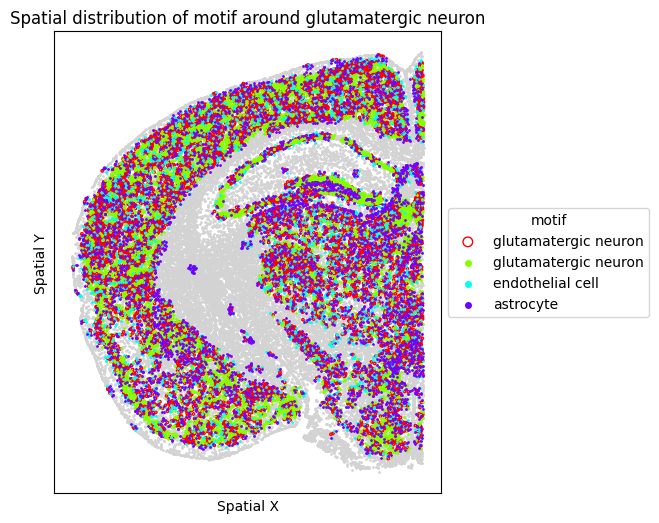

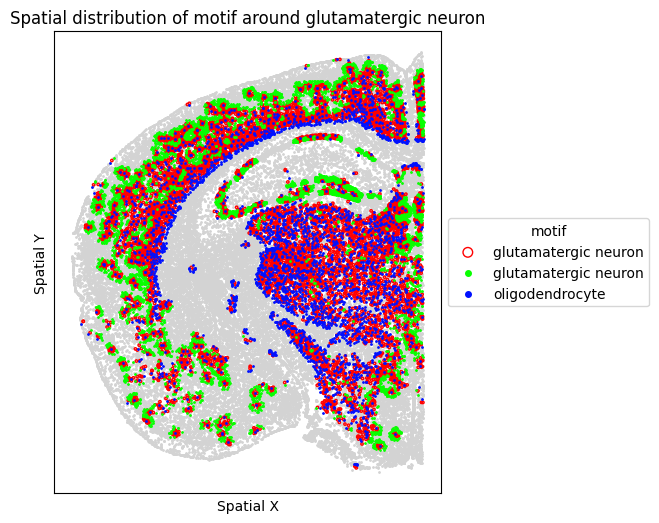

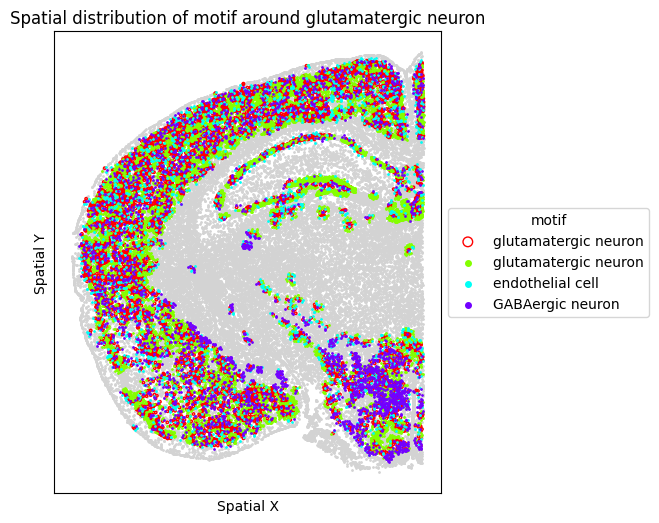

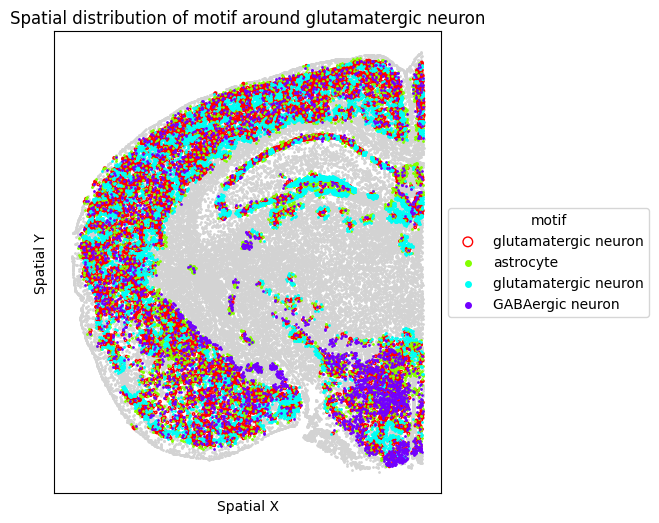

In [15]:
# Visualize motif distribution in a single representative FOV
target_fov = "WB-MERFISH-animal2-coronal_49"
target_sp = [sp for sp in spm.spatial_queries if sp.dataset == target_fov][0]

for m in motif_glut_coronal_df["motifs"]:
    target_sp.plot_motif_celltype(
        ct=anchor_ct,
        motif=m,
        max_dist=max_dist,
        figsize=(5, 6),
    )

## 6. Cross-cell Gene-Gene Covariation

Identify gene pairs with spatially-specific cross-cell correlation between
glutamatergic neurons and their motif neighbors.

In [16]:
print(f"Anchor: {anchor_ct}, max_dist: {max_dist}")
print(f"Coronal datasets: {coronal_ds}")

Anchor: glutamatergic neuron, max_dist: 5
Coronal datasets: ['WB-MERFISH-animal1-coronal', 'WB-MERFISH-animal2-coronal']


In [17]:
motif2 = ['oligodendrocyte', 'glutamatergic neuron']
covarying_genes_m2 = spm.compute_gene_gene_correlation_by_type(
    ct=anchor_ct,
    motif=motif2,
    dataset=coronal_ds,
    max_dist=max_dist,
)

Computing covarying genes using expression data ...
Only one non-center cell type in motif: ['oligodendrocyte']. Using compute_gene_gene_correlation method.
No genes specified. Using union of genes across all selected FOVs ...
Gene coverage: 1120 genes in all FOVs, 1120 genes total (union)
Analyzing 1120 genes across 213 FOVs

Step 1: Computing and accumulating statistics across FOVs

... (1523 lines omitted) ...
Total gene pairs analyzed: 1254400
Significant pairs: 151030


In [18]:
covarying_genes_m2 = covarying_genes_m2[covarying_genes_m2['if_significant']]
covarying_genes_m2

,gene_center,gene_motif,corr_neighbor,corr_non_neighbor,p_value_test1,delta_corr_test1,corr_center_no_motif,p_value_test2,delta_corr_test2,combined_score,adj-pval-test1,adj-pval-test2,if_significant,cell_type
0,Prkcd,Prkcd,0.483658,-0.025477,0.0,0.509135,0.066700,0.0,0.416958,133.383376,0.0,0.0,True,oligodendrocyte
1,Grik3,Slc17a7,0.200625,-0.046645,0.0,0.247271,-0.169207,0.0,0.369833,99.919199,0.0,0.0,True,oligodendrocyte
2,Tnnt1,Prkcd,0.318601,-0.015084,0.0,0.333685,0.008595,0.0,0.310006,95.132929,0.0,0.0,True,oligodendrocyte
3,Grid2ip,Prkcd,0.353341,-0.021876,0.0,0.375217,0.065240,0.0,0.288100,94.270543,0.0,0.0,True,oligodendrocyte
4,Rgs16,Prkcd,0.316480,-0.020070,0.0,0.336550,0.023593,0.0,0.292886,91.795601,0.0,0.0,True,oligodendrocyte
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1254395,Gucy1a1,Slc17a7,-0.098372,0.052502,0.0,-0.150874,0.172281,0.0,-0.270654,-70.415942,0.0,0.0,True,oligodendrocyte
1254396,Cux2,Slc17a7,-0.146541,0.030721,0.0,-0.177261,0.150265,0.0,-0.296806,-78.282743,0.0,0.0,True,oligodendrocyte
1254397,Otof,Slc17a7,-0.153165,0.065437,0.0,-0.218603,0.149220,0.0,-0.302385,-83.175139,0.0,0.0,True,oligodendrocyte
1254398,Calb1,Slc17a7,-0.166215,0.052068,0.0,-0.218283,0.136621,0.0,-0.302836,-83.241135,0.0,0.0,True,oligodendrocyte


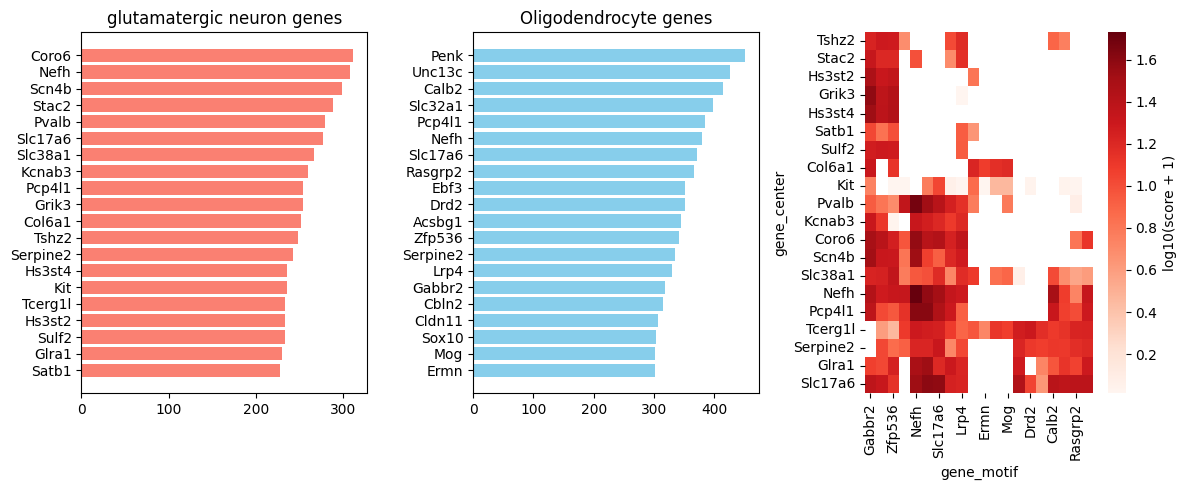

In [19]:
# Covarying gene pairs for motif2 (oligodendrocyte)
oligo_pos = covarying_genes_m2[covarying_genes_m2['cell_type'] == 'oligodendrocyte'].copy()
oligo_pos = oligo_pos[oligo_pos['combined_score'] > 0]

top_gene_center = pd.DataFrame(oligo_pos['gene_center'].value_counts().head(20))[::-1]
top_gene_motif = pd.DataFrame(oligo_pos['gene_motif'].value_counts().head(20))[::-1]

fig, axs = plt.subplots(1, 3, figsize=(12, 5))

axs[0].barh(top_gene_center.index.tolist(), top_gene_center['count'].tolist(), color='salmon')
axs[0].set_title(f'{anchor_ct} genes')

axs[1].barh(top_gene_motif.index.tolist(), top_gene_motif['count'].tolist(), color='skyblue')
axs[1].set_title('Oligodendrocyte genes')

# Heatmap of top50 gene pairs
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import pdist

top20_center = oligo_pos['gene_center'].value_counts().head(20).index.tolist()
top20_motif = oligo_pos['gene_motif'].value_counts().head(20).index.tolist()
sub = oligo_pos[oligo_pos['gene_center'].isin(top20_center) & oligo_pos['gene_motif'].isin(top20_motif)]

pivot = sub.pivot_table(index='gene_center', columns='gene_motif', values='combined_score', fill_value=0)
mask = (pivot == 0)
data = np.log10(pivot + 1)

row_order = dendrogram(linkage(pdist(data), method='average'), no_plot=True)['leaves']
col_order = dendrogram(linkage(pdist(data.T), method='average'), no_plot=True)['leaves']

sns.heatmap(
    data.iloc[row_order, col_order],
    mask=mask.iloc[row_order, col_order],
    cmap='Reds',
    cbar_kws={'label': 'log10(score + 1)'},
    ax=axs[2],
)

plt.tight_layout()


## 7. Regional Stratification: Isocortex Analysis

Since glutamatergic neurons are most abundant in the Isocortex, we construct a subset
containing only Isocortex cells and repeat the covariation analysis to examine whether
motif-specific gene programs are preserved in a single brain region.

In [20]:
# Subset to Isocortex cells from coronal sections
adatas_coronal_isocortex = []
dataset_names_coronal_isocortex = []

adatas_coronal = [adatas_fov[i] for i in range(len(adatas_fov)) if "coronal" in adatas_fov[i].uns["title"]]

for adata in adatas_coronal:
    sub_data = adata[adata.obs["major_brain_region"] == "Isocortex"].copy()
    adatas_coronal_isocortex.append(sub_data)
    dataset_names_coronal_isocortex.append(adata.uns["title"])

print(f"Isocortex FOVs: {len(adatas_coronal_isocortex)}")
print(f"Isocortex cells: {sum(a.n_obs for a in adatas_coronal_isocortex):,}")

Isocortex FOVs: 213
Isocortex cells: 1,337,180


In [21]:
spm_coronal_isocortex = spatial_query_multi(
    adatas=adatas_coronal_isocortex,
    datasets=dataset_names_coronal_isocortex,
    spatial_key=spatial_key,
    label_key=label_key,
    build_gene_index=False,
    feature_name=feature_name,
    if_lognorm=False,
    if_normalize_spatial_coord=True
)

Replacing _ with hyphen in WB_MERFISH_animal2_coronal.
Replacing _ with hyphen in WB_MERFISH_animal2_coronal.
Replacing _ with hyphen in WB_MERFISH_animal2_coronal.
Replacing _ with hyphen in WB_MERFISH_animal2_coronal.
Replacing _ with hyphen in WB_MERFISH_animal2_coronal.
Replacing _ with hyphen in WB_MERFISH_animal2_coronal.
Replacing _ with hyphen in WB_MERFISH_animal2_coronal.
Replacing _ with hyphen in WB_MERFISH_animal2_coronal.
Replacing _ with hyphen in WB_MERFISH_animal2_coronal.
Replacing _ with hyphen in WB_MERFISH_animal2_coronal.
... (1053 lines omitted) ...
Scale factor: 0.0881
build_gene_index is False. Using adata.X for gene expression analysis.


In [22]:
motif0 = motif_glut_coronal_df['motifs'].iloc[0]

covarying_isocortex_motif0 = spm_coronal_isocortex.compute_gene_gene_correlation_by_type(
    ct=anchor_ct, 
    motif=motif0,
    dataset=coronal_ds,
    max_dist=max_dist,
)

Computing covarying genes using expression data ...
Analyzing 2 non-center cell types in motif: ['astrocyte', 'endothelial cell']
Selected 213 FOVs for analysis
No genes specified. Using union of genes across all selected FOVs ...
Gene coverage: 1120 genes in all FOVs, 1120 genes total (union)
Analyzing 1120 genes across 213 FOVs

Step 1: Computing Correlation-3 (Center without motif vs Neighbors)
... (938 lines omitted) ...

Results prepared and sorted


In [23]:
motif3 = motif_glut_coronal_df['motifs'].iloc[3]

covarying_isocortex_motif3 = spm_coronal_isocortex.compute_gene_gene_correlation_by_type(
    ct=anchor_ct, 
    motif=motif3,
    dataset=coronal_ds,
    max_dist=max_dist,
)

Computing covarying genes using expression data ...
Analyzing 2 non-center cell types in motif: ['GABAergic neuron', 'astrocyte']
Selected 213 FOVs for analysis
No genes specified. Using union of genes across all selected FOVs ...
Gene coverage: 1120 genes in all FOVs, 1120 genes total (union)
Analyzing 1120 genes across 213 FOVs

Step 1: Computing Correlation-3 (Center without motif vs Neighbors)
... (938 lines omitted) ...

Results prepared and sorted


In [24]:
covarying_isocortex_motif3_astro = covarying_isocortex_motif3[covarying_isocortex_motif3['if_significant']]
covarying_isocortex_motif3_astro = covarying_isocortex_motif3_astro[covarying_isocortex_motif3_astro['cell_type'] == 'astrocyte']

covarying_isocortex_motif0_astro = covarying_isocortex_motif0[covarying_isocortex_motif0['if_significant']]
covarying_isocortex_motif0_astro = covarying_isocortex_motif0_astro[covarying_isocortex_motif0_astro['cell_type'] == 'astrocyte']


In [25]:
rank_genes_glut_astro_isocortex = spm_coronal_isocortex.test_score_difference(
    result_A=covarying_isocortex_motif0_astro,
    result_B=covarying_isocortex_motif3_astro,
    percentile_threshold=99
)

Significant pairs in A: 6652
Significant pairs in B: 7929
Pairs that are significant in at least one group: 9350
Time to compute percentiles: 0.11 seconds.

Score Difference Test Results
Total pairs tested: 5231
Outlier pairs (percentile > 99 or < 1): 105
... (4 lines omitted) ...
Mean score difference: 0.199
Std score difference: 5.155


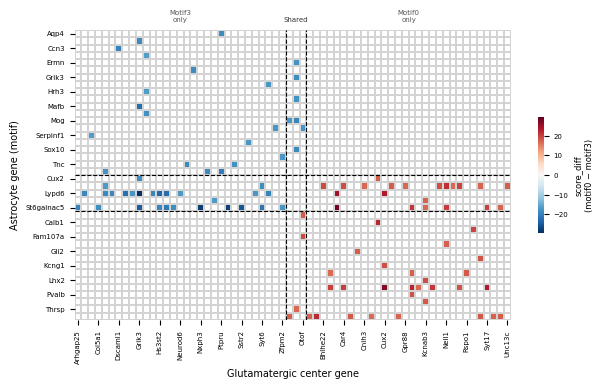

In [26]:

df_plot = rank_genes_glut_astro_isocortex[rank_genes_glut_astro_isocortex['outlier_direction'] != 'not_outlier'].copy()

m0 = df_plot[df_plot['outlier_direction'] == 'higher_in_A'].nlargest(100, 'score_diff')
m3 = df_plot[df_plot['outlier_direction'] == 'lower_in_A'].nsmallest(100, 'score_diff')
df_plot = pd.concat([m0, m3])

center_shared  = sorted(set(m0['gene_center']) & set(m3['gene_center']))
center_m0_only = sorted(set(m0['gene_center']) - set(m3['gene_center']))
center_m3_only = sorted(set(m3['gene_center']) - set(m0['gene_center']))
center_genes   = center_m3_only + center_shared + center_m0_only

motif_shared   = sorted(set(m0['gene_motif']) & set(m3['gene_motif']))
motif_m0_only  = sorted(set(m0['gene_motif']) - set(m3['gene_motif']))
motif_m3_only  = sorted(set(m3['gene_motif']) - set(m0['gene_motif']))
motif_genes    = motif_m3_only + motif_shared + motif_m0_only

n_row = len(center_genes)
n_col = len(motif_genes)
row_idx = {g: i for i, g in enumerate(center_genes)}
col_idx = {g: i for i, g in enumerate(motif_genes)}

mat = np.full((n_row, n_col), np.nan)
for _, row in df_plot.iterrows():
    mat[row_idx[row['gene_center']], col_idx[row['gene_motif']]] = row['score_diff']

vmax = np.nanmax(np.abs(mat))
mat_df = pd.DataFrame(mat, index=center_genes, columns=motif_genes)

mat_df_T = mat_df.T  # rows = astrocyte genes, cols = glut genes

fig, ax = plt.subplots(figsize=(max(4, n_row * 0.1), max(3, n_col * 0.1)))

sns.heatmap(
    mat_df_T,
    cmap='RdBu_r',
    center=0,
    vmin=-vmax, vmax=vmax,
    linewidths=0.01,
    linecolor='lightgrey',
    mask=np.isnan(mat.T),
    cbar_kws={'label': 'score_diff\n(motif0 − motif3)', 'shrink': 0.4},
    ax=ax,
)

cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=5)
cbar.set_label('score_diff\n(motif0 − motif3)', fontsize=6)

# Dividing lines — seaborn heatmap: col x goes 0..n_col, row y goes 0..n_row
n_m3_only_col = len(motif_m3_only)
n_shared_col  = len(motif_shared)
n_m3_only_row = len(center_m3_only)
n_shared_row  = len(center_shared)

# After transpose: rows = motif genes, cols = center genes
# Dashed lines: column boundaries from original row splits, row boundaries from col splits
for x in [n_m3_only_row, n_m3_only_row + n_shared_row]:
    ax.axvline(x, color='black', linewidth=0.8, linestyle='--')
for y in [n_m3_only_col, n_m3_only_col + n_shared_col]:
    ax.axhline(y, color='black', linewidth=0.8, linestyle='--')

ax.set_xlabel('Glutamatergic center gene', fontsize=7)
ax.set_ylabel('Astrocyte gene (motif)', fontsize=7)
ax.tick_params(axis='x', labelsize=5)
ax.tick_params(axis='y', labelsize=5)

# Region annotations: columns are center genes (motif3-only | shared | motif0-only)
ax.text(n_m3_only_row / 2,                           -1.2, 'Motif3\nonly', ha='center', fontsize=5, color='#555')
ax.text(n_m3_only_row + n_shared_row / 2,            -1.2, 'Shared',       ha='center', fontsize=5, color='#333')
ax.text(n_m3_only_row + n_shared_row + len(center_m0_only) / 2, -1.2, 'Motif0\nonly', ha='center', fontsize=5, color='#555')

plt.tight_layout()
plt.show()
